In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize']=(12,5)

df = pd.read_csv("C:/Users/pooja kumari/OneDrive/Desktop/Data-Analysis-Projects/Pro-7-Airbnb NYC Dataset Data Analysis/AB_NYC_2019.csv")

print(f"Rows :{df.shape[0]:,}")
print(f"Columns :{df.shape[1]:,}")
print(f"\nColumn name:")
print(df.columns.tolist())


Rows :48,895
Columns :16

Column name:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


In [2]:
print("First 5 rows:")

df.head()

First 5 rows:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [4]:
df.describe().round(2)

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.00,4.889500e+04,48895.00,48895.00,48895.00,48895.00,48895.00,38843.00,48895.00,48895.00
mean,19017143.24,6.762001e+07,40.73,-73.95,152.72,7.03,23.27,1.37,7.14,112.78
std,10983108.39,7.861097e+07,0.05,0.05,240.15,20.51,44.55,1.68,32.95,131.62
min,2539.00,2.438000e+03,40.50,-74.24,0.00,1.00,0.00,0.01,1.00,0.00
25%,9471945.00,7.822033e+06,40.69,-73.98,69.00,1.00,1.00,0.19,1.00,0.00
50%,19677284.00,3.079382e+07,40.72,-73.96,106.00,3.00,5.00,0.72,1.00,45.00
75%,29152178.50,1.074344e+08,40.76,-73.94,175.00,5.00,24.00,2.02,2.00,227.00
max,36487245.00,2.743213e+08,40.91,-73.71,10000.00,1250.00,629.00,58.50,327.00,365.00


In [5]:
# missing values count
missing_count = df.isnull().sum()

# percentage of missing values
missing_percent = (df.isnull().sum () / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count' : missing_count,
    'Missing percent' : missing_percent.round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print("=== Missing Values Report ====")

print(missing_df)
        


=== Missing Values Report ====
                   Missing Count  Missing percent
name                          16             0.03
host_name                     21             0.04
last_review                10052            20.56
reviews_per_month          10052            20.56


In [6]:
df['name'] = df['name'].fillna('No Name')
df['host_name'] = df['host_name'].fillna('Unknown')

df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

df['last_review'] = df['last_review'].fillna('No Review')

print(f"\nMissing values after filling:")

print(df.isnull().sum())


Missing values after filling:
id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


In [7]:
# check duplicate
print(f"Duplicates before: {df.duplicated().sum()}")

# Remove
df = df.drop_duplicates()

# Check

print(f"Duplicate after: {df.duplicated().sum()}")
print(f"Dataset size: {df.shape}")




Duplicates before: 0
Duplicate after: 0
Dataset size: (48895, 16)


In [8]:
# Worng values fix
print(f"Price=0 listings: {(df['price'] == 0).sum()}")
df = df[df['price'] >0]

print(f"Min nights > 365:{(df['minimum_nights'] >365).sum()}")
df = df[df['minimum_nights'] <=365]

print(f"Rows after cleaning: {df.shape[0]:,}")
      

Price=0 listings: 11
Min nights > 365:14
Rows after cleaning: 48,870


In [9]:
#  data type fix

mask = df['last_review'] != 'No Review'
df.loc[mask, 'last_review'] = pd.to_datetime(df.loc[mask, 'last_review']
    )
print(df.dtypes)


id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


In [10]:

df['last_review'] = pd.to_datetime(
    df['last_review'],
    errors='coerce'   
)

print("Data type of last_review:")
print(df['last_review'].dtype)


Data type of last_review:
datetime64[ns]


In [11]:
# Data cleaning summary
print(f"Final Rows   :{df.shape[0]:,}")
print(f"Final Columns :{df.shape[1]}")
print(f"Missing Values :{df.isnull().sum().sum()}")
print(f"Duplicates ;{df.duplicated().sum()}")
print(F"Price Range ;${df['price'].min()} -${df['price'].max()}")
print(f"Room Types :{df['room_type'].unique()}")
print(f"Areas :{df['neighbourhood_group'].unique()}")

Final Rows   :48,870
Final Columns :16
Missing Values :10043
Duplicates ;0
Price Range ;$10 -$10000
Room Types :['Private room' 'Entire home/apt' 'Shared room']
Areas :['Brooklyn' 'Manhattan' 'Queens' 'Staten Island' 'Bronx']


# Room Type Distribution

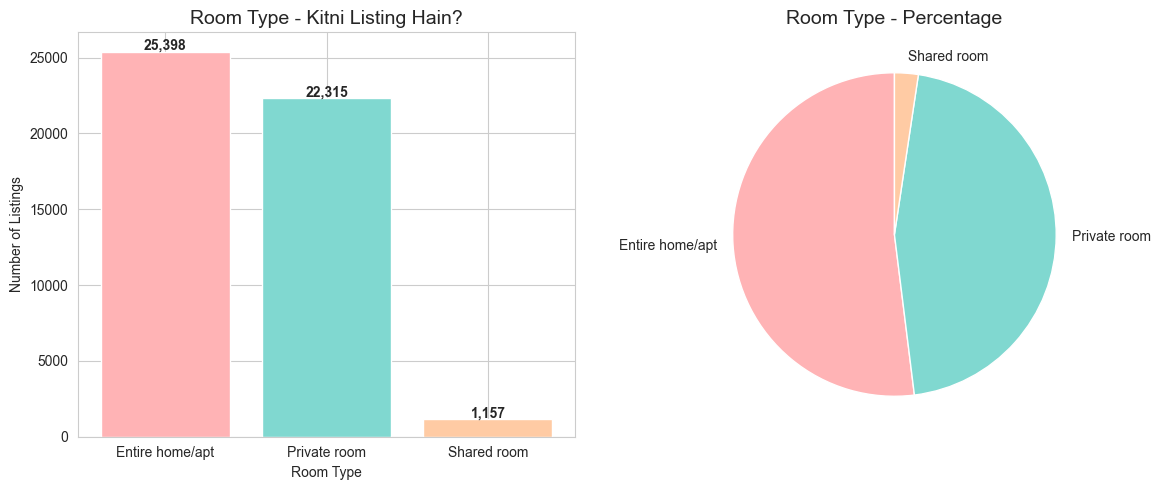


===== ROOM TYPE COUNTS =====
room_type
Entire home/apt    25398
Private room       22315
Shared room         1157
Name: count, dtype: int64


In [12]:
#  Room Type Distribution
plt.figure(figsize=(12,5))

#left chart : bar chart

plt.subplot(1,2,1)
room_counts = df['room_type'].value_counts()
colors = ['#FFB3B5', '#80D8D0', '#FFCBA4']

plt.bar(room_counts.index, room_counts.values,color=colors)

plt.title('Room Type - Kitni Listing Hain?',fontsize=14)
plt.xlabel('Room Type')
plt.ylabel('Number of Listings')

for i, v in enumerate(room_counts.values):
    plt.text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

#  Right chart: pie chart
plt.subplot(1, 2, 2)
plt.pie(room_counts.values,
        labels=room_counts.index,
        colors=colors,
        startangle=90)

plt.title('Room Type - Percentage', fontsize=14)

plt.tight_layout()
plt.savefig('room_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n===== ROOM TYPE COUNTS =====")
print(room_counts)

#  Price Distribution

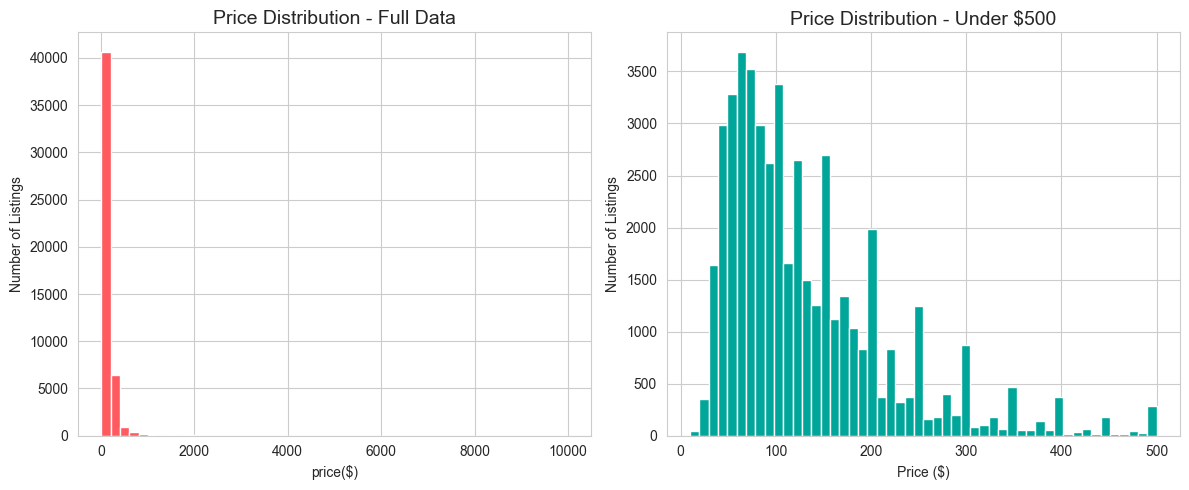


====== Price Statistics =======
Average Price  : $153
Median Price   : $106
Lowest Price   : $10
Highest Price  : $10000


In [13]:
#  Price Distribution
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df['price'], bins=50,
         color= '#FF5A5F', edgecolor='white')

plt.title('Price Distribution - Full Data', fontsize=14)
plt.xlabel('price($)')
plt.ylabel('Number of Listings')


plt.subplot(1,2,2)

df_filterd = df[df['price'] <= 500]

plt.hist(df_filterd['price'], bins=50,
         color='#00A699', edgecolor='white')

plt.title('Price Distribution - Under $500', fontsize=14)
plt.xlabel('Price ($)')
plt.ylabel('Number of Listings')

plt.tight_layout()
plt.savefig('Price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n====== Price Statistics =======")
print(f"Average Price  : ${df['price'].mean():.0f}")
print(F"Median Price   : ${df['price'].median():.0f}")
print(f"Lowest Price   : ${df['price'].min()}")
print(f"Highest Price  : ${df['price'].max()}")





#  Neighbourhood Analysis


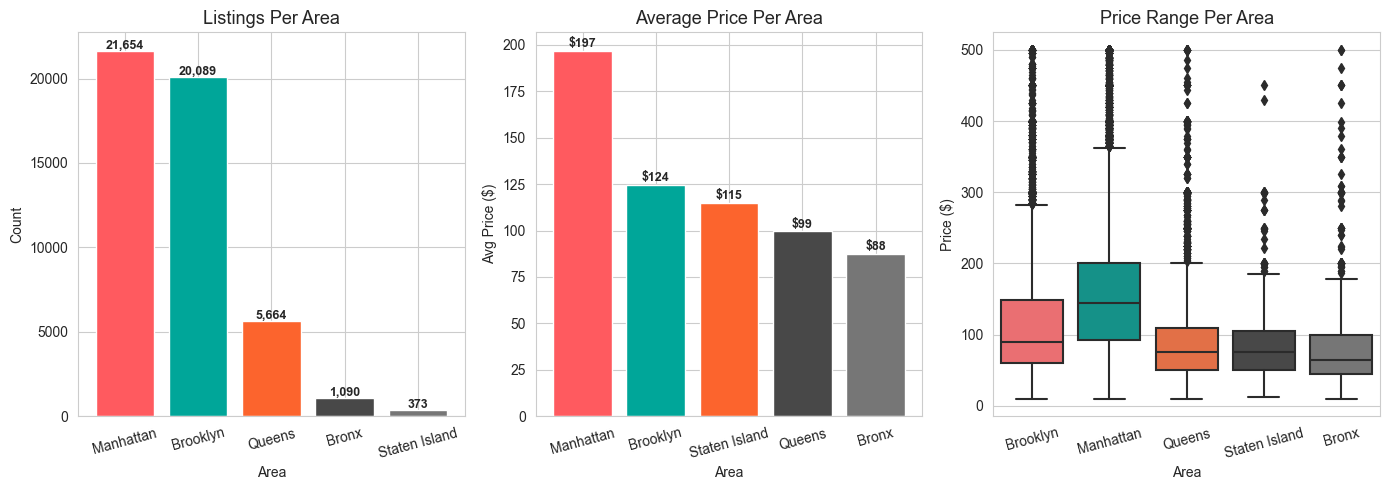


=== AVERAGE PRICE PER AREA ===
neighbourhood_group
Manhattan        197.0
Brooklyn         124.0
Staten Island    115.0
Queens            99.0
Bronx             88.0
Name: price, dtype: float64


In [14]:
plt.figure(figsize=(14, 5))

colors5 = ['#FF5A5F', '#00A699', '#FC642D', '#484848', '#767676']

# ── Left: Listings count ──
plt.subplot(1, 3, 1)

neigh_counts = df['neighbourhood_group'].value_counts()

plt.bar(neigh_counts.index, neigh_counts.values, color=colors5)
plt.title('Listings Per Area', fontsize=13)
plt.xlabel('Area')
plt.ylabel('Count')
plt.xticks(rotation=15)

for i, v in enumerate(neigh_counts.values):
    plt.text(i, v + 100, f'{v:,}', ha='center', 
             fontsize=9, fontweight='bold')

# ── Middle: Average price ──
plt.subplot(1, 3, 2)

avg_price = df.groupby('neighbourhood_group')['price'].mean()
avg_price = avg_price.sort_values(ascending=False)

plt.bar(avg_price.index, avg_price.values, color=colors5)
plt.title('Average Price Per Area', fontsize=13)
plt.xlabel('Area')
plt.ylabel('Avg Price ($)')
plt.xticks(rotation=15)

for i, v in enumerate(avg_price.values):
    plt.text(i, v + 2, f'${v:.0f}', ha='center', 
             fontsize=9, fontweight='bold')

# ── Right: Boxplot ──
plt.subplot(1, 3, 3)

df_box = df[df['price'] <= 500]

sns.boxplot(data=df_box,
            x='neighbourhood_group',
            y='price',
            palette=colors5)

plt.title('Price Range Per Area', fontsize=13)
plt.xlabel('Area')
plt.ylabel('Price ($)')
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('neighbourhood_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== AVERAGE PRICE PER AREA ===")
print(avg_price.round(0))

# Room Type vs Price

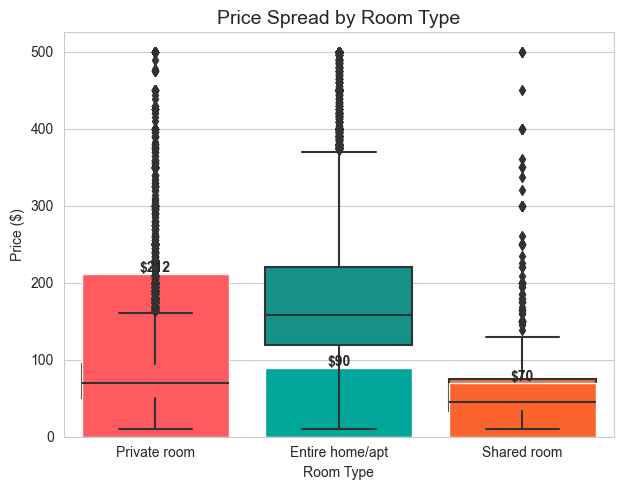


 ======Average Price by Room Type =====
room_type
Entire home/apt    212.0
Private room        90.0
Shared room         70.0
Name: price, dtype: float64


In [15]:
plt.figure(figsize=(12,5))

#  Left: Average price
plt.subplot(1,2,1)

avg_room = df.groupby('room_type')['price'].mean()
avg_room = avg_room.sort_values(ascending=False)

colors3 = ['#FF5A5F', '#00A699', '#FC642D']


plt.bar(avg_room.index, avg_room.values, color=colors3)
plt.title('Average Price by Room Type', fontsize=14)
plt.xlabel('Room Type')
plt.ylabel('Average Price ($)')


for i, v in enumerate(avg_room.values):
    plt.text(i, v +  2, f'${v:.0f}',
             ha='center', fontweight='bold')

# ── Right: Boxplot 

plt.subplot(1,2,1)

df_box2 = df[df['price'] <= 500]
sns.boxplot(data=df_box2,
            x='room_type',
            y='price',
            palette=colors3)

plt.title('Price Spread by Room Type', fontsize=14)
plt.xlabel('Room Type')
plt.ylabel('Price ($)')

plt.tight_layout()
plt.savefig('roomtype_price.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n ======Average Price by Room Type =====")
print(avg_room.round(0))

#  NYC Geographic Map

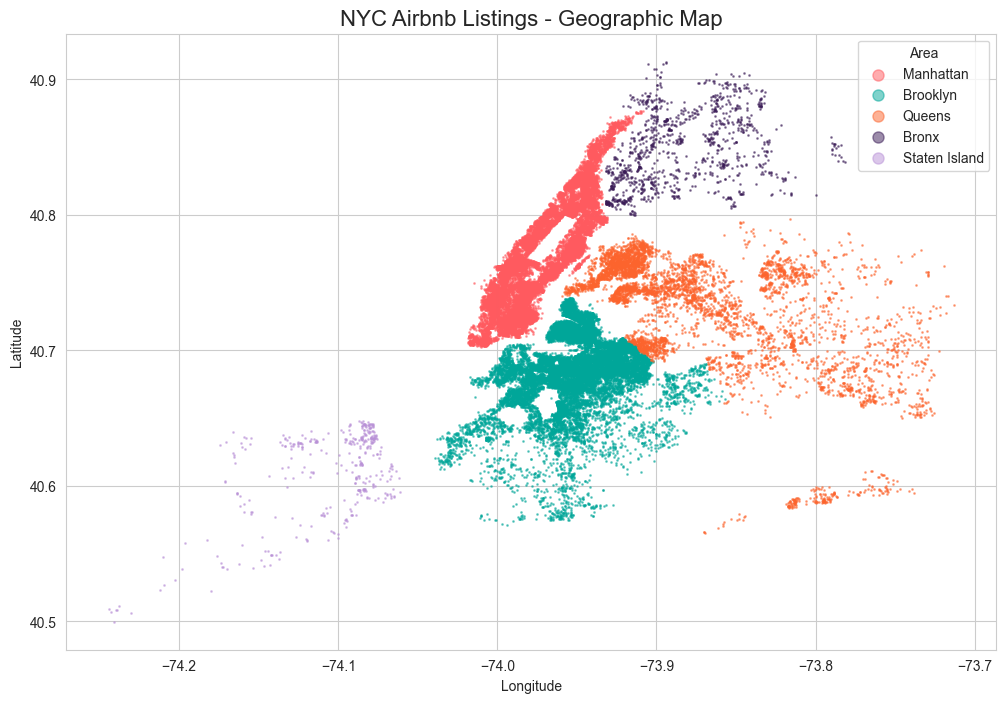


Listings per area:
neighbourhood_group
Manhattan        21654
Brooklyn         20089
Queens            5664
Bronx             1090
Staten Island      373
Name: count, dtype: int64


In [16]:
plt.figure(figsize=(12,8))

colors_map = {
    'Manhattan'    : '#FF5A5F',
    'Brooklyn'     : '#00A699',
    'Queens'       : '#FC642D',
    'Bronx'        : '#3A1B56',
    'Staten Island': '#B991D7'
}

for area, color in colors_map.items():
    subset = df[df['neighbourhood_group'] == area]


    plt.scatter(subset['longitude'],
                subset['latitude'],
                       c=color,
                       label=area,
                       s=1,
                       alpha=0.5)


plt.title('NYC Airbnb Listings - Geographic Map', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Area', markerscale=8)

plt.savefig('nyc_map.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nListings per area:")
print(df['neighbourhood_group'].value_counts())

# Top 10 Neighbourhoods

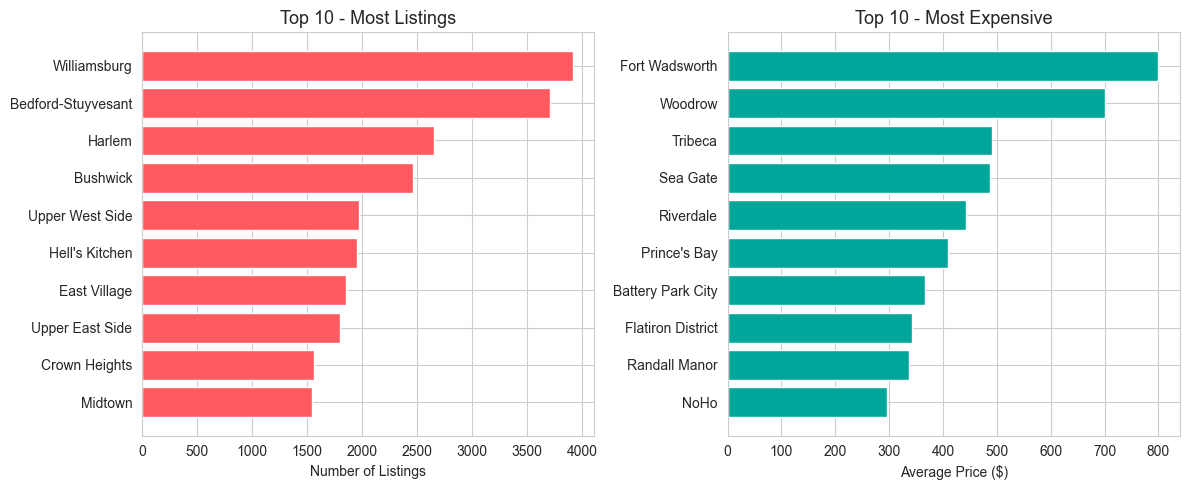

In [17]:
plt.figure(figsize=(12, 5))

# ── Left: Most listings ──
plt.subplot(1, 2, 1)

top_neigh = df['neighbourhood'].value_counts().head(10)

plt.barh(top_neigh.index, top_neigh.values, color='#FF5A5F')
plt.title('Top 10 - Most Listings', fontsize=13)
plt.xlabel('Number of Listings')
plt.gca().invert_yaxis()

# ── Right: Most expensive ──
plt.subplot(1, 2, 2)

exp_neigh = df.groupby('neighbourhood')['price'].mean()
exp_neigh = exp_neigh.sort_values(ascending=False).head(10)

plt.barh(exp_neigh.index, exp_neigh.values, color='#00A699')
plt.title('Top 10 - Most Expensive', fontsize=13)
plt.xlabel('Average Price ($)')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig('top_neighbourhoods.png', dpi=150, bbox_inches='tight')
plt.show()

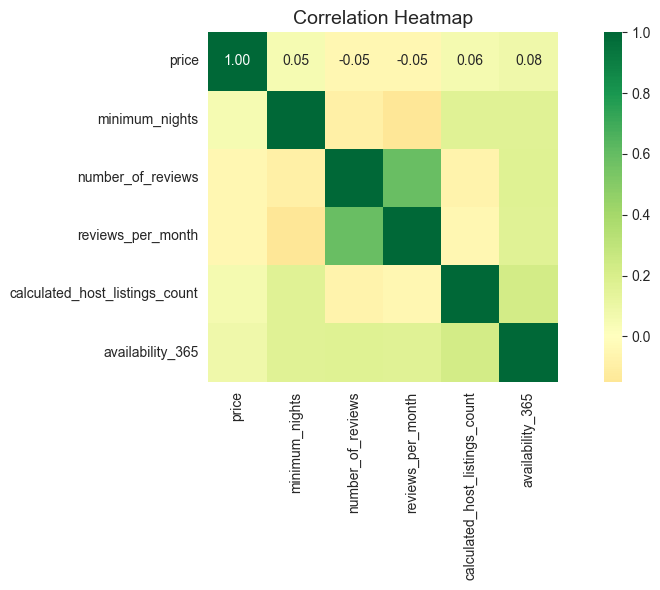

In [18]:
plt.figure(figsize=(10, 6))


numeric_cols = ['price', 'minimum_nights', 
                'number_of_reviews', 'reviews_per_month',
                'calculated_host_listings_count', 
                'availability_365']

corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True)

plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
print("=" * 50)
print("   AIRBNB NYC 2019 - KEY BUSINESS INSIGHTS")
print("=" * 50)

print(f"\n LISTINGS:")
print(f"   Total Listings      : {df.shape[0]:,}")
print(f"   Most Listings Area  : {df['neighbourhood_group'].value_counts().index[0]}")
print(f"   Least Listings Area : {df['neighbourhood_group'].value_counts().index[-1]}")

print(f"\n PRICE:")
print(f"   Average Price       : ${df['price'].mean():.0f}")
print(f"   Median Price        : ${df['price'].median():.0f}")
print(f"   Most Expensive Area : {df.groupby('neighbourhood_group')['price'].mean().idxmax()}")
print(f"   Cheapest Area       : {df.groupby('neighbourhood_group')['price'].mean().idxmin()}")

print(f"\n ROOM TYPE:")
print(f"   Most Common         : {df['room_type'].value_counts().index[0]}")
print(f"   Most Expensive      : {df.groupby('room_type')['price'].mean().idxmax()}")
print(f"   Cheapest            : {df.groupby('room_type')['price'].mean().idxmin()}")

print(f"\n REVIEWS:")
print(f"   Avg Reviews/Month   : {df['reviews_per_month'].mean():.2f}")
print(f"   Most Reviewed Area  : {df.groupby('neighbourhood_group')['number_of_reviews'].mean().idxmax()}")

print("=" * 50)

   AIRBNB NYC 2019 - KEY BUSINESS INSIGHTS

 LISTINGS:
   Total Listings      : 48,870
   Most Listings Area  : Manhattan
   Least Listings Area : Staten Island

 PRICE:
   Average Price       : $153
   Median Price        : $106
   Most Expensive Area : Manhattan
   Cheapest Area       : Bronx

 ROOM TYPE:
   Most Common         : Entire home/apt
   Most Expensive      : Entire home/apt
   Cheapest            : Shared room

 REVIEWS:
   Avg Reviews/Month   : 1.09
   Most Reviewed Area  : Staten Island


In [ ]:
#  Power BI 

save_path = "C:/Users/pooja kumari/OneDrive/Desktop/Data-Analysis-Projects/Pro-7-Airbnb NYC Dataset Data Analysis/"

df.to_csv(save_path + 'airbnb_nyc_cleaned.csv', index=False)

area_summary = df.groupby('neighbourhood_group').agg(
    Total_Listings   = ('id', 'count'),
    Avg_Price        = ('price', 'mean'),
    Median_Price     = ('price', 'median'),
    Avg_Reviews      = ('number_of_reviews', 'mean'),
    Avg_Availability = ('availability_365', 'mean')
).round(2).reset_index()

area_summary.to_csv(save_path + 'area_summary.csv', index=False)

room_summary = df.groupby('room_type').agg(
    Total_Listings = ('id', 'count'),
    Avg_Price      = ('price', 'mean'),
    Min_Price      = ('price', 'min'),
    Max_Price      = ('price', 'max')
).round(2).reset_index()

room_summary.to_csv(save_path + 'room_summary.csv', index=False)

print("✅ Files save !")
print(f"Location: {save_path}")
print("1. airbnb_nyc_cleaned.csv")
print("2. area_summary.csv")
print("3. room_summary.csv")